In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../datasets/disasters_new_feats/all_new_feats.csv')
feats = df.drop(columns=['BEGIN_LAT','BEGIN_LON'])
feats.head()

,PRECIPITATION,TMIN,TMAX,ELEVATION,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
0,1133.73,10.03,22.38,186.71,5.62,0.0,0.157,0.039,0.708,0.012,0.0,0.085,1248.1,237.1
1,1144.69,9.98,22.38,184.07,6.52,0.0,0.173,0.048,0.702,0.007,0.0,0.070,528.2,236.5
2,1433.45,7.41,20.58,596.98,39.69,0.0,0.056,0.006,0.936,0.001,0.0,0.001,431.3,363.6
3,1442.06,8.76,21.05,280.25,11.47,0.0,0.379,0.023,0.527,0.069,0.0,0.001,842.2,462.1
4,1327.57,8.59,20.74,323.11,15.72,0.0,0.405,0.016,0.567,0.006,0.0,0.005,1563.3,457.8


## Distribution

In [8]:
feats.describe()

,PRECIPITATION,TMIN,TMAX,ELEVATION,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
count,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000,436146.000000
mean,947.156164,6.678690,18.936949,424.092992,8.573953,0.006438,0.323128,0.237719,0.319253,0.062526,0.000077,0.050733,907.098177,586.279865
std,402.499916,5.153733,4.615038,475.971296,8.734535,0.025355,0.252748,0.268299,0.295409,0.178877,0.003045,0.111304,1025.918355,467.734911
min,50.780000,-31.030000,5.150000,-63.020000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.100000,0.000000
25%,646.280000,2.490000,15.240000,118.510000,3.550000,0.000000,0.095000,0.043000,0.077000,0.000000,0.000000,0.000000,305.600000,164.800000
50%,1022.510000,6.530000,18.770000,291.620000,5.800000,0.000000,0.292000,0.116000,0.193000,0.002000,0.000000,0.003000,698.100000,506.800000
75%,1222.890000,9.900000,22.470000,475.260000,9.390000,0.001000,0.521000,0.428000,0.569000,0.019000,0.000000,0.041000,1087.600000,1014.000000
max,7301.100000,26.100000,33.050000,3665.080000,116.620000,0.885000,0.969000,0.999000,1.000000,1.000000,0.542000,0.922000,30548.000000,1635.400000


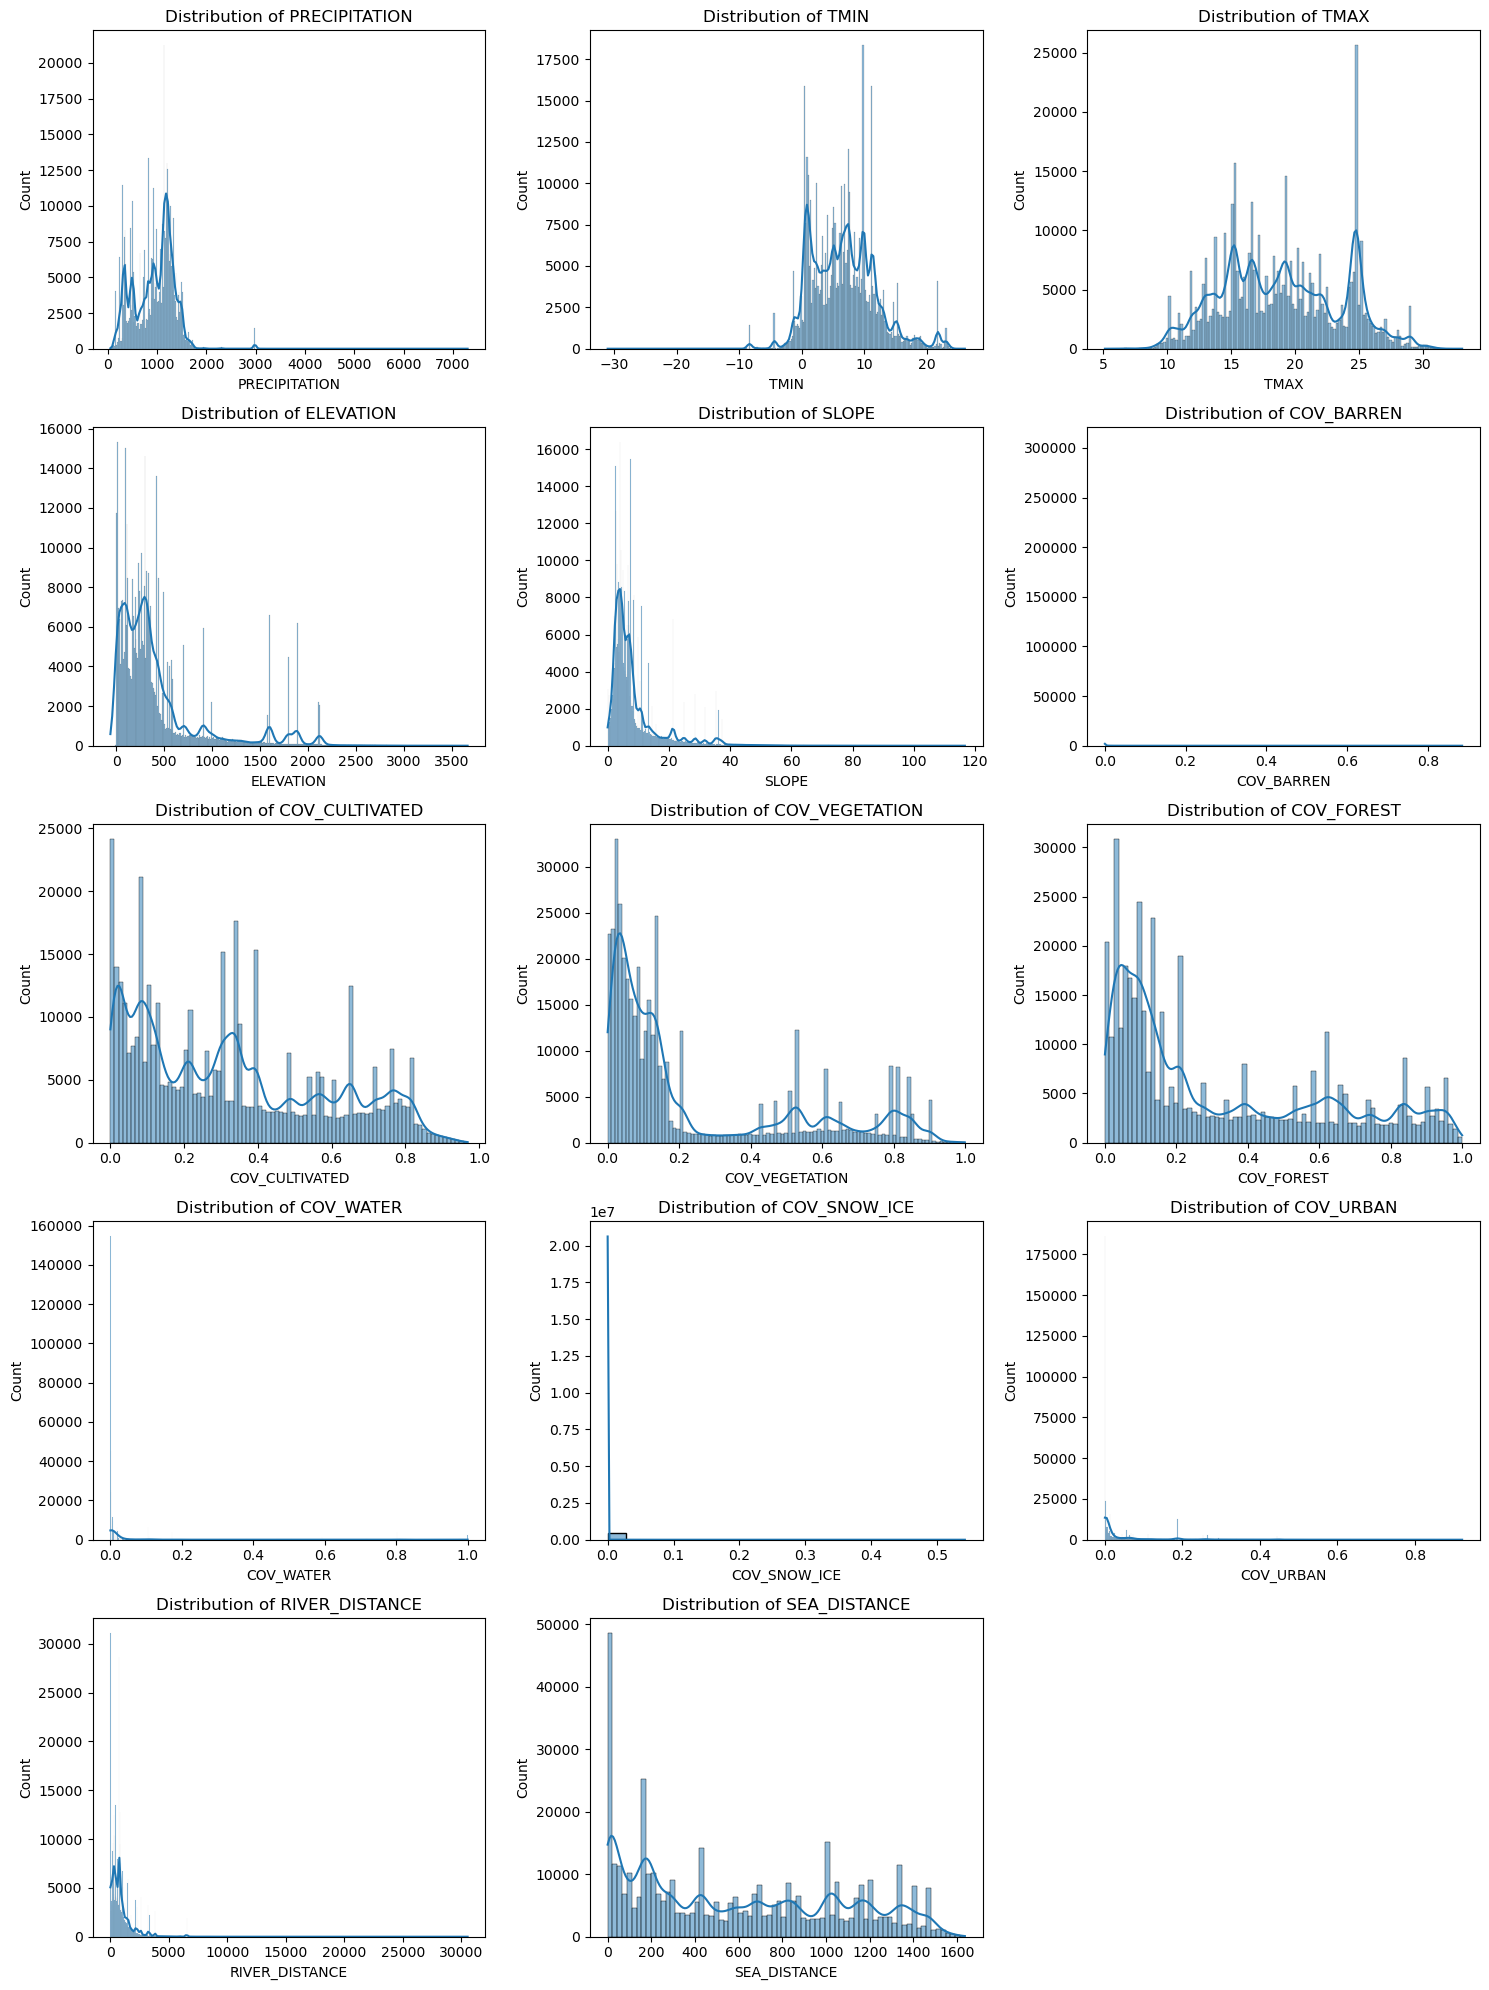

In [ ]:
cols = feats.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(feats[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
scaler = StandardScaler()
std_feats = scaler.fit_transform(feats)
std_feats = pd.DataFrame(std_feats, columns=feats.columns)
std_feats.describe().T

,count,mean,std,min,25%,50%,75%,max
PRECIPITATION,436146.0,-3.714438e-16,1.000001,-2.227025,-0.747519,0.187215,0.685054,15.786217
TMIN,436146.0,3.800457e-16,1.000001,-7.316781,-0.812750,-0.028851,0.625045,3.768401
TMAX,436146.0,-1.229284e-15,1.000001,-2.987400,-0.801067,-0.036175,0.765553,3.058061
ELEVATION,436146.0,3.146194e-16,1.000001,-1.023410,-0.642021,-0.278322,0.107500,6.809215
SLOPE,436146.0,1.044604e-16,1.000001,-0.980471,-0.575183,-0.317585,0.093428,12.369996
COV_BARREN,436146.0,-1.008763e-16,1.000001,-0.253911,-0.253911,-0.253911,-0.214471,34.650500
COV_CULTIVATED,436146.0,-5.575567e-16,1.000001,-1.278460,-0.902591,-0.123159,0.782882,2.555398
COV_VEGETATION,436146.0,1.545728e-16,1.000001,-0.886023,-0.725754,-0.453669,0.709214,2.837439
COV_FOREST,436146.0,3.296727e-16,1.000001,-1.080717,-0.820060,-0.427383,0.845432,2.304430
COV_WATER,436146.0,-2.733696e-17,1.000001,-0.349547,-0.349547,-0.338366,-0.243329,5.240890


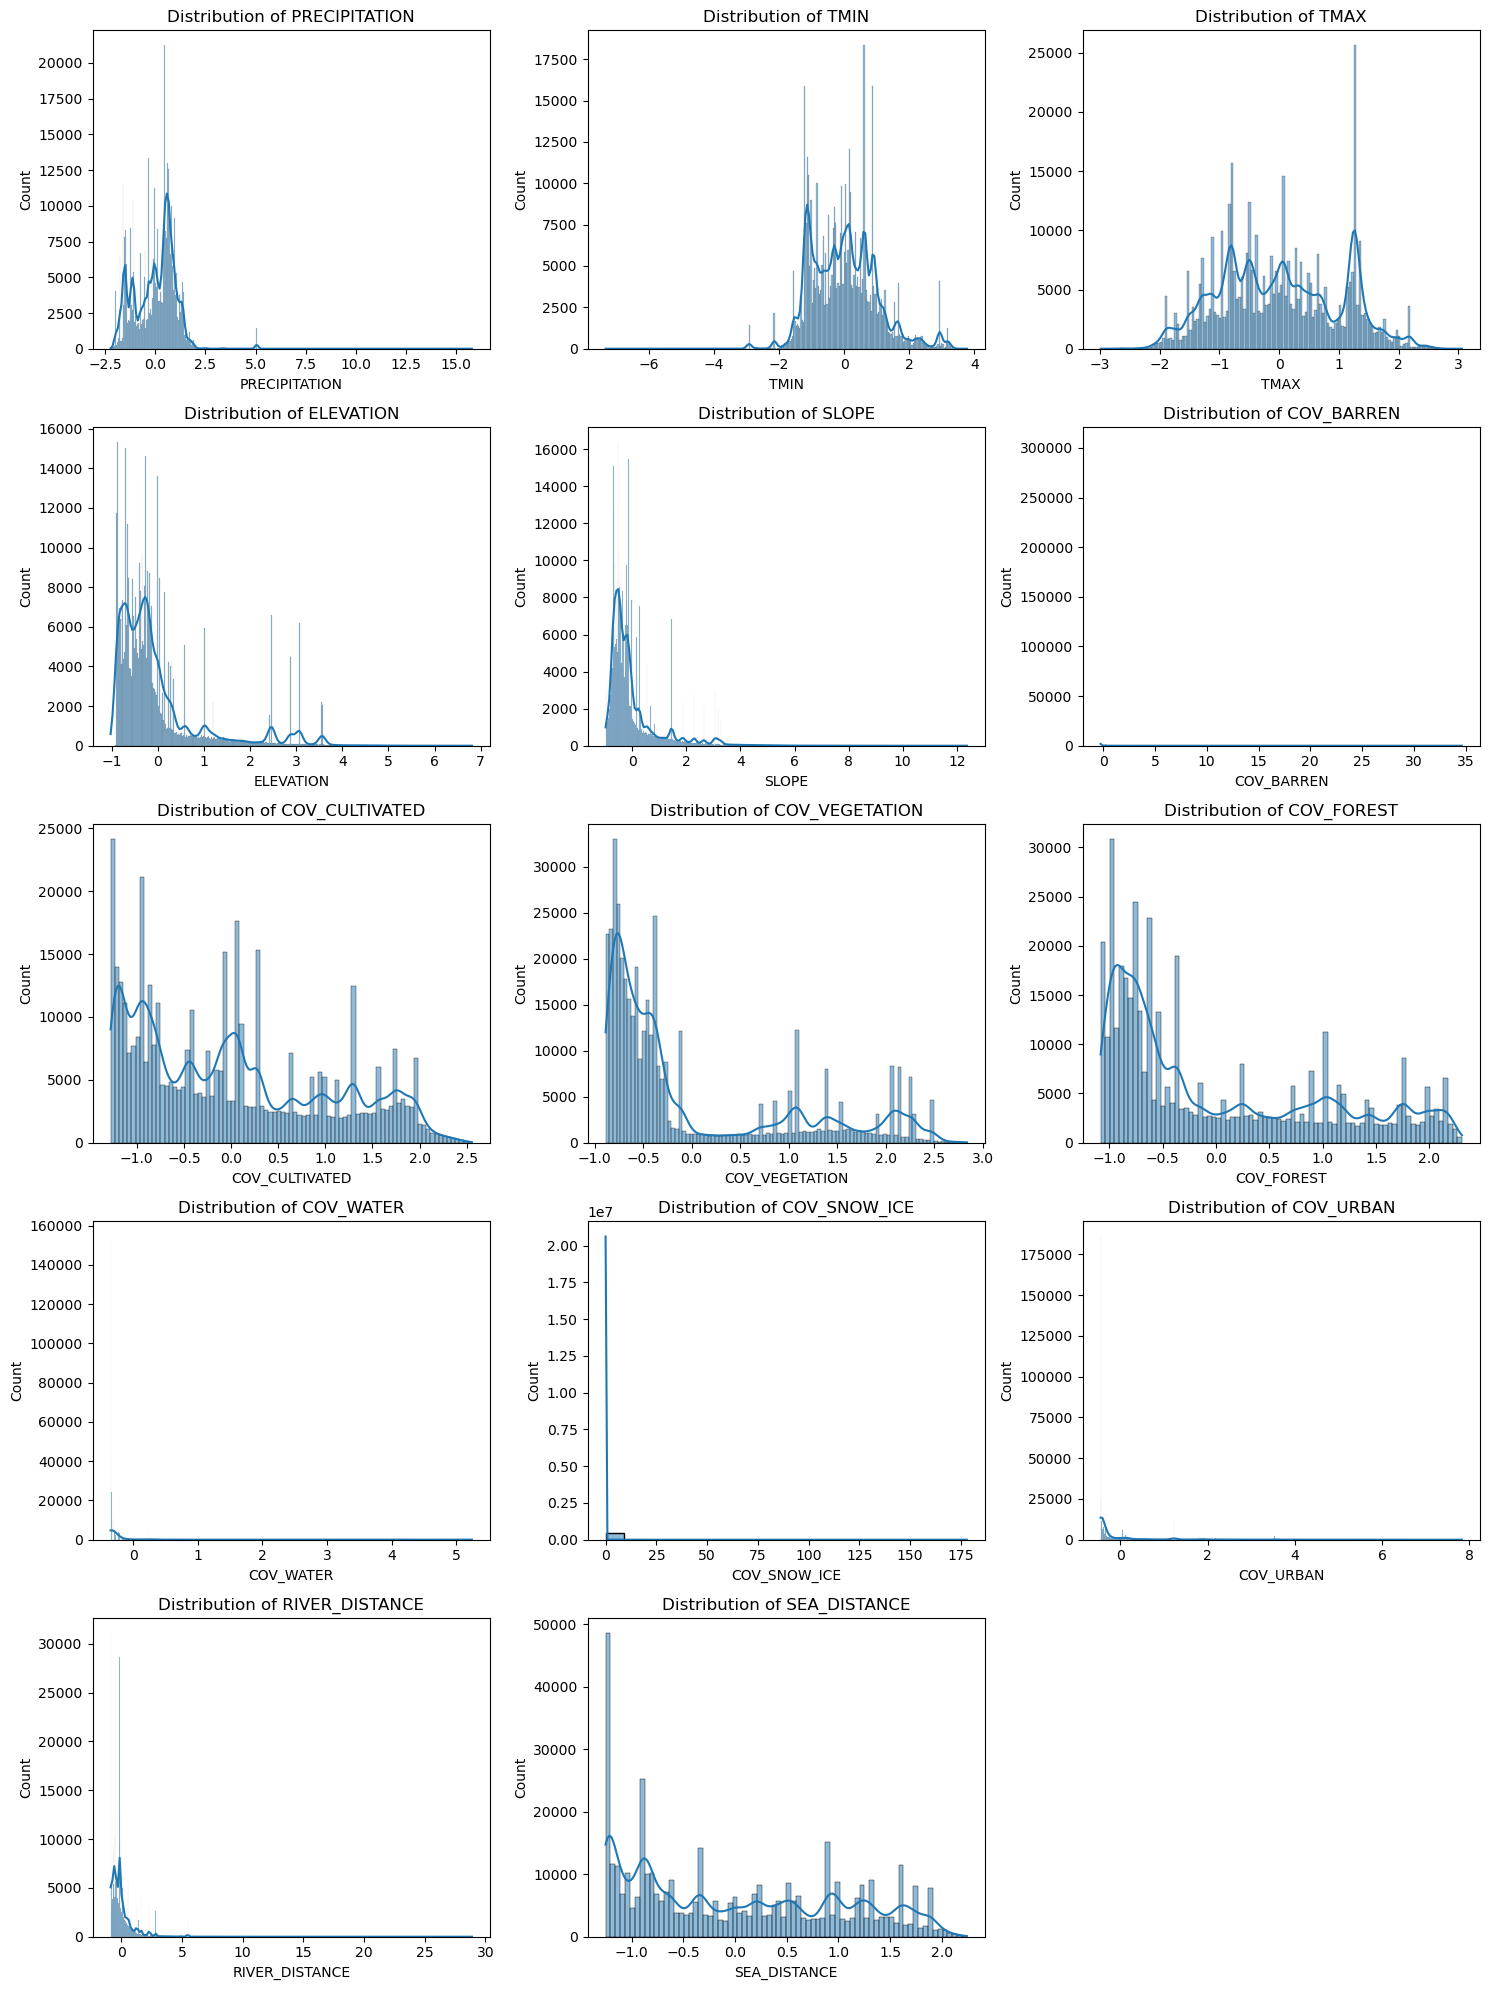

In [7]:
cols = std_feats.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(std_feats[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlation

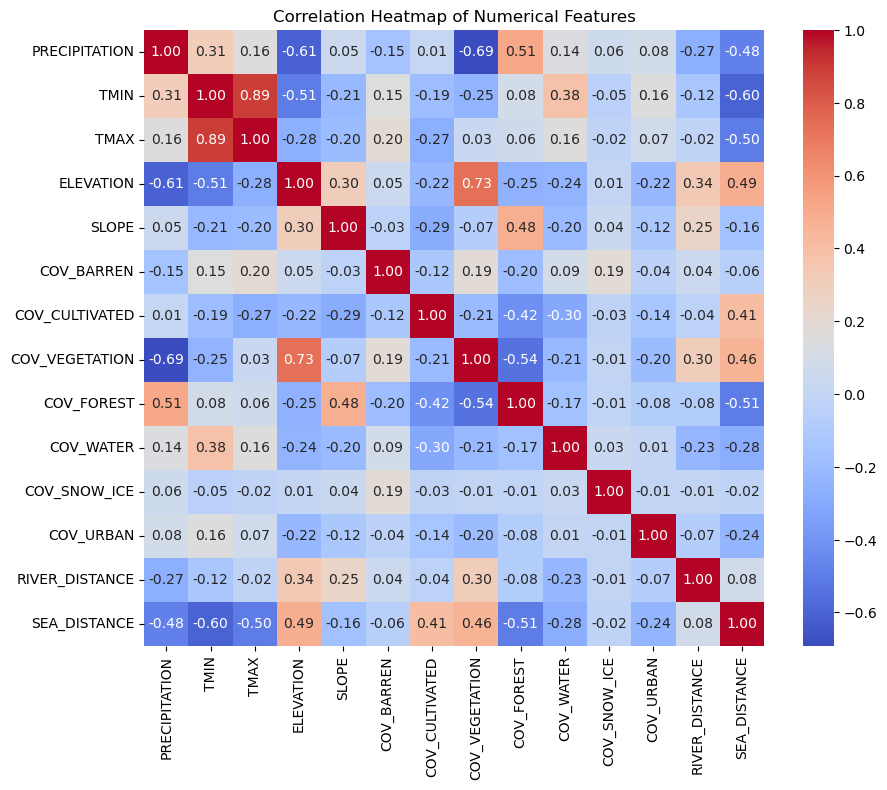

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(feats.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()